# Fused Pipeline v3: Semi-Supervised ResNet-50 + Wavelet Hybrid — Breast Cancer Classification

**v1 -> v2 -> v3**, based on running each version and comparing actual results:

- **v1** scored *worse* (70.6% macro F1 test) than the plain (non-semi-supervised) ResNet50+Wavelet
  hybrid (72.2%), with training F1 hitting 99.9% while validation F1 sat around 70% -- classic
  overfitting from fine-tuning too much of the backbone on a noisy, augmentation-free training set.
- **v2** fixed that overfitting (train F1 89% vs val F1 70% -- a healthy gap) but the *final* test
  score barely moved (69.4%), because a second, previously-hidden problem was masked by the first:
  v2's own per-class logging showed self-training accepting pseudo-labels for "Normal" 2,600 times
  across 5 iterations (78% of everything accepted) while "Malignant" was accepted only 118 times
  (3.5%) -- the model was overconfident on the easy class and self-training quietly amplified that,
  actively re-skewing a dataset that was built to be balanced.
- **v3** (this version) keeps v2's overfitting fixes and adds per-class-aware pseudo-label
  acceptance so self-training can't do that again.

1. **Data augmentation — flip only** (unchanged from v2). The upstream preprocessing pipeline already
   balances classes with synthetic augmented copies mixed indistinguishably into
   `labeled_train`/`unlabeled_train`, so resampling-based augmentation applied again here would
   compound blur on top of those copies. A flip needs no resampling, so it adds diversity without
   that risk.
2. **Lighter fine-tuning** (unchanged from v2): unfreeze fewer ResNet-50 layers (15 instead of 30),
   fewer epochs (25 instead of 40), plus L2 weight decay and higher dropout in the fusion head.
3. **Early stopping inside each self-training iteration** (unchanged from v2), so a bad iteration
   can't push the model further into memorizing noisy pseudo-labels.
4. **NEW in v3 — per-class pseudo-label thresholds + a hard per-class cap.** `PER_CLASS_THRESHOLD`
   raises the bar for Normal (0.93) and eases it slightly for Benign/Malignant (0.85), and
   `MAX_ACCEPT_PER_CLASS_PER_ITER` (200) hard-caps how many of any one class can be accepted in a
   single self-training iteration regardless of threshold. This directly targets the Normal-flooding
   behavior v2's per-class logging (kept in this version too) exposed.

### Pipeline phases (unchanged)
- **Phase 1** — train the frozen-backbone hybrid model on `labeled_train` only (now augmented).
- **Phase 2** — iterative self-training, now with per-class threshold + cap, early stopping, and
  per-class acceptance logging.
- **Phase 3** — lighter fine-tuning of the ResNet-50 backbone on the final combined set.
- **Phase 4** — evaluate on train/val/test, classification report, confusion matrix.

### Expected data layout (unchanged)
```
Semi_Supervised_Balanced/
    labeled_train/<class>/*.jpg
    unlabeled_train/<class or single dummy folder>/*.jpg
    val/<class>/*.jpg
    test/<class>/*.jpg
```


In [1]:
# ==========================================================
# GPU CHECK
# ==========================================================
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow Version: ", tf.__version__)

Num GPUs Available:  1
TensorFlow Version:  2.10.0


In [2]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import os
import shutil
import random
import numpy as np
import cv2
import pywt
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate, BatchNormalization
)
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
from tensorflow.keras.metrics import Precision, Recall
import tensorflow_addons as tfa
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")


start
done1


In [3]:
# ==========================================================
# SEMI-SUPERVISED DATASET DIRECTORY (BALANCED)
# ==========================================================
# Same directory the semi-supervised EfficientNetB3 notebook uses --
# labeled_train / unlabeled_train / val / test, built by the preprocessing
# pipeline (P3_fixed_final_Pipeline_v11). labeled_train/unlabeled_train/val
# come from the augmented, balanced pool; test is the raw, untouched,
# held-out set shared across all your models so results stay comparable.
print("start")

base_path = r"D:\Thesis_folder\Preprocessed_Pipeline\Semi_Supervised_Balanced"

labeled_dir = os.path.join(base_path, "labeled_train")
unlabeled_dir = os.path.join(base_path, "unlabeled_train")
val_dir = os.path.join(base_path, "val")
test_dir = os.path.join(base_path, "test")
train_combined_dir = os.path.join(base_path, "train_combined")

for split_dir in [labeled_dir, unlabeled_dir, val_dir, test_dir]:
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(
            f"'{split_dir}' not found. Run the preprocessing pipeline "
            "(P3_fixed_final_Pipeline_v11) through the semi-supervised split step first."
        )
    classes_found = [d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]
    counts = {cls: len(os.listdir(os.path.join(split_dir, cls))) for cls in classes_found}
    print(f"{os.path.basename(split_dir)}: {counts}")

print("done1")

start
labeled_train: {'Benign': 1714, 'Malignant': 1714, 'Normal': 1715}
unlabeled_train: {'Benign': 4286, 'Malignant': 4286, 'Normal': 4285}
val: {'Benign': 931, 'Malignant': 1239, 'Normal': 795}
test: {'Benign': 888, 'Malignant': 1266, 'Normal': 789}
done1


In [4]:
# ==========================================================
# CONFIGURATION & PARAMETERS  (v2)
# ==========================================================
print("start")

IMAGE_SIZE = (288, 288)
MODEL_INPUT_SIZE = (288, 288, 3)
NUM_CLASSES = 3
BATCH_SIZE = 32
EPOCHS_PHASE1 = 150

WAVELET_NAME = "db1"
WAVELET_LEVEL = 2

# --- Semi-supervised self-training schedule ---
NUM_ITERATIONS = 5
EPOCHS_PER_ITERATION = 7
CONFIDENCE_THRESHOLD = 0.90   # fallback threshold for any class not in PER_CLASS_THRESHOLD

# NEW (v3): v2's run showed self-training accepting pseudo-labels overwhelmingly for
# "Normal" (2,600 of 3,321 accepted across all iterations = 78%) while Malignant got
# almost nothing (118 = 3.5%). That's the model being over-confident on the easy class
# and starving the harder ones -- exactly the kind of thing a single global threshold
# can't fix. Per-class thresholds + a hard cap address it directly:
PER_CLASS_THRESHOLD = {
    "Normal": 0.93,     # raise the bar for the class that was flooding
    "Benign": 0.85,     # ease slightly -- it's a harder class, model is rarely overconfident here
    "Malignant": 0.85,  # same -- Malignant was nearly shut out entirely at 0.90
}
MAX_ACCEPT_PER_CLASS_PER_ITER = 200   # NEW: hard cap so no single class can dominate an
                                        # iteration even if its threshold is still cleared often

SELFTRAIN_EARLYSTOP_PATIENCE = 3   # NEW: stop an iteration's fit early if val_f1 stalls,
                                    # instead of always burning all EPOCHS_PER_ITERATION.

# --- Fine-tuning schedule (v2: lighter than v1) ---
EPOCHS_FINETUNE = 25              # was 40
FINETUNE_UNFREEZE_LAST_N = 15     # was 30 -- unfreeze less of the backbone

# --- Regularization (v2: new) ---
DROPOUT_RATE = 0.4                # was 0.3 throughout
L2_REG = 1e-4                     # new L2 weight decay on the fusion head's Dense layers

# --- Data augmentation (v2: new) ---
AUGMENT_TRAIN = True   # applied only to train_labeled_generator / train_combined_generator,
                        # NEVER to val_generator, test_generator, or the unlabeled scoring generator

# NOTE: class weighting / Malignant boost stays removed, per prior decision -- all classes
# are treated equally in the loss. CLASS_WEIGHT_MODE is left here as an easy lever if Benign
# (the weakest class in both v1 and the plain baseline) still needs it after these changes.
CLASS_WEIGHT_MODE = None   # set to 'balanced' to try sklearn-style inverse-frequency weights

print("done1")


start
done1


In [5]:
# ==========================================================
# WAVELET FEATURE EXTRACTION
# ==========================================================
# 2D Discrete Wavelet Transform on the grayscale image; every sub-band
# (approximation + horizontal/vertical/diagonal detail, at every decomposition
# level) is summarised with mean, std and normalised energy. This gives a
# compact, complementary texture descriptor that is concatenated with the
# ResNet-50 deep features.
print("start")

def extract_wavelet_features(image_rgb, wavelet=WAVELET_NAME, level=WAVELET_LEVEL):
    '''
    image_rgb: HxWx3 uint8 or float array (0-255 range)
    Returns: 1D float32 feature vector
    '''
    gray = cv2.cvtColor(image_rgb.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    coeffs = pywt.wavedec2(gray, wavelet=wavelet, level=level)

    features = []
    for idx, c in enumerate(coeffs):
        if idx == 0:
            sub_bands = [c]                 # approximation coefficients
        else:
            sub_bands = list(c)             # (cH, cV, cD) detail coefficients

        for sub in sub_bands:
            features.append(sub.mean())
            features.append(sub.std())
            features.append(np.sum(sub.astype(np.float64) ** 2) / sub.size)

    return np.array(features, dtype=np.float32)


def get_wavelet_feature_dim():
    dummy = np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.uint8)
    return extract_wavelet_features(dummy).shape[0]


WAVELET_FEATURE_DIM = get_wavelet_feature_dim()
print(f"Wavelet feature vector length: {WAVELET_FEATURE_DIM}")
print("done1")

start
Wavelet feature vector length: 21
done1


In [6]:
# ==========================================================
# AUGMENTATION (v2b, REVISED)
# ==========================================================
# IMPORTANT: the upstream preprocessing pipeline already balances classes by
# inserting synthetic augmented copies (~10% of images) directly into
# labeled_train / unlabeled_train, with no way to tell those apart from
# genuine originals at this stage. Rotation/zoom/jitter are resampling
# operations -- applying them AGAIN on top of an already-augmented image
# compounds interpolation blur and washes out the fine texture detail the
# wavelet branch depends on, and it lands hardest on whichever class was
# balanced with the most synthetic copies (almost certainly Benign, the
# weakest class in every run so far) -- the opposite of what we want.
#
# So this version restricts on-the-fly augmentation to a horizontal flip
# only. A flip is a pure pixel re-index, not a resampling operation, so it
# never compounds blur even when applied to an already-augmented image. It
# still doubles the effective diversity of every epoch (each image can be
# seen in either orientation) without the double-degradation risk that
# rotation/zoom/brightness jitter would carry here.
print("start")

def augment_image(img_rgb):
    if random.random() < 0.5:
        return np.ascontiguousarray(np.fliplr(img_rgb))
    return img_rgb

print("done1")


start
done1


In [7]:
# ==========================================================
# DUAL-INPUT DATA GENERATOR (ResNet-50 image branch + wavelet branch)  (v2)
# ==========================================================
# Same as v1, with one addition: an `augment` flag. When True (train_labeled_
# generator / train_combined_generator only), each image is put through
# augment_image() BEFORE the wavelet features are computed and BEFORE
# preprocess_input, so both branches always see the same (possibly augmented)
# pixels. val_generator, test_generator, and the unlabeled scoring generator
# always use augment=False -- augmenting evaluation or pseudo-label scoring
# would make results non-reproducible and would bias pseudo-label confidence.
class ResNetWaveletGenerator(Sequence):
    def __init__(self, directory, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                 num_classes=NUM_CLASSES, shuffle=True, labeled=True,
                 class_indices=None, exclude_filepaths=None, augment=False):
        self.directory = directory
        self.image_size = image_size
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.labeled = labeled
        self.augment = augment

        self.class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
        self.class_indices = class_indices or {name: i for i, name in enumerate(self.class_names)}

        exclude_filepaths = exclude_filepaths or set()

        self.filepaths = []
        self.labels = []
        for cls in self.class_names:
            cls_dir = os.path.join(directory, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                    fpath = os.path.join(cls_dir, fname)
                    if fpath in exclude_filepaths:
                        continue
                    self.filepaths.append(fpath)
                    self.labels.append(self.class_indices.get(cls, 0))

        self.labels = np.array(self.labels)
        self.indices = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return max(1, int(np.ceil(len(self.filepaths) / self.batch_size)))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_images = np.zeros((len(batch_idx), *self.image_size, 3), dtype=np.float32)
        batch_wavelets = np.zeros((len(batch_idx), WAVELET_FEATURE_DIM), dtype=np.float32)
        batch_labels = np.zeros((len(batch_idx), self.num_classes), dtype=np.float32)

        for i, fi in enumerate(batch_idx):
            img_bgr = cv2.imread(self.filepaths[fi])
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_rgb = cv2.resize(img_rgb, self.image_size)

            if self.augment:
                img_rgb = augment_image(img_rgb)

            # Wavelet branch computed on the (possibly augmented) raw 0-255 image,
            # BEFORE ResNet's preprocess_input rescales/centres it.
            batch_wavelets[i] = extract_wavelet_features(img_rgb)
            batch_images[i] = preprocess_input(img_rgb.astype(np.float32))

            if self.labeled:
                batch_labels[i, self.labels[fi]] = 1.0

        if self.labeled:
            return [batch_images, batch_wavelets], batch_labels
        # NOTE (kept from v1): must stay a 2-tuple (x, None), not a bare list --
        # Keras's Sequence protocol would otherwise silently drop the wavelet input.
        return [batch_images, batch_wavelets], None

    def filepaths_for_batch(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        return [self.filepaths[i] for i in batch_idx]

print("ResNetWaveletGenerator (v2, with augmentation) ready")


ResNetWaveletGenerator (v2, with augmentation) ready


In [8]:
# ==========================================================
# BUILD LABELED / VAL / TEST GENERATORS  (v2: train generator is augmented)
# ==========================================================
print("start")

train_labeled_generator = ResNetWaveletGenerator(
    labeled_dir, shuffle=True, labeled=True, augment=AUGMENT_TRAIN
)

# Val/test must share the exact same class_indices mapping as train_labeled,
# and are NEVER augmented.
val_generator = ResNetWaveletGenerator(
    val_dir, shuffle=False, labeled=True, augment=False,
    class_indices=train_labeled_generator.class_indices
)

test_generator = ResNetWaveletGenerator(
    test_dir, shuffle=False, labeled=True, augment=False,
    class_indices=train_labeled_generator.class_indices
)

class_names = train_labeled_generator.class_names
print("Class indices:", train_labeled_generator.class_indices)

assert len(class_names) == NUM_CLASSES, (
    f"Expected {NUM_CLASSES} classes, found {len(class_names)}. "
    "Rerun the preprocessing pipeline from a clean state."
)
assert set(val_generator.filepaths).isdisjoint(set(test_generator.filepaths)), (
    "val_generator and test_generator appear to overlap."
)

print("done1")


start
Class indices: {'Benign': 0, 'Malignant': 1, 'Normal': 2}
done1


In [9]:
# ==========================================================
# CLASS WEIGHTS -- still disabled by default (v2 keeps the prior decision)
# ==========================================================
if CLASS_WEIGHT_MODE == 'balanced':
    from sklearn.utils.class_weight import compute_class_weight
    classes_arr = np.arange(NUM_CLASSES)
    weights = compute_class_weight('balanced', classes=classes_arr, y=train_labeled_generator.labels)
    class_weight = {i: w for i, w in enumerate(weights)}
    print("Class weighting: balanced ->", class_weight)
else:
    class_weight = None
    print("Class weighting: disabled (class_weight=None)")

print("Class names:", class_names)


Class weighting: disabled (class_weight=None)
Class names: ['Benign', 'Malignant', 'Normal']


In [10]:
# ==========================================================
# MODEL DEFINITION: ResNet-50 (image branch) + Wavelet MLP (feature branch)  (v2)
# ==========================================================
# Same dual-branch architecture as v1. NEW: L2 weight decay on the fusion
# head's Dense layers, and dropout raised from 0.3 -> DROPOUT_RATE (0.4) --
# both aimed directly at the 99.9%-train / 70%-val overfitting gap seen in v1.
print("start")

f1_metric = tfa.metrics.F1Score(num_classes=NUM_CLASSES, average='macro', name='f1_score')
precision_metric = Precision(name='precision')
recall_metric = Recall(name='recall')

def get_ResNet50_Wavelet_Hybrid(learning_rate=1e-4):
    # ---- Image branch: ResNet-50 (frozen, ImageNet weights) ----
    image_input = Input(shape=MODEL_INPUT_SIZE, name="image_input")
    base_model = ResNet50(
        input_tensor=image_input,
        weights='imagenet',
        include_top=False
    )
    base_model.trainable = False

    x_img = GlobalAveragePooling2D()(base_model.output)
    x_img = Dropout(DROPOUT_RATE)(x_img)

    # ---- Wavelet branch: small MLP over handcrafted features ----
    wavelet_input = Input(shape=(WAVELET_FEATURE_DIM,), name="wavelet_input")
    x_wav = BatchNormalization()(wavelet_input)
    x_wav = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(x_wav)
    x_wav = Dropout(DROPOUT_RATE)(x_wav)

    # ---- Fusion + classifier head ----
    fused = Concatenate()([x_img, x_wav])
    fused = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(fused)
    fused = Dropout(DROPOUT_RATE)(fused)
    output = Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=regularizers.l2(L2_REG))(fused)

    model = Model(inputs=[image_input, wavelet_input], outputs=output)

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        loss="categorical_crossentropy",
        metrics=["accuracy", f1_metric, precision_metric, recall_metric],
        optimizer=optimizer
    )

    return model, base_model

model, base_model = get_ResNet50_Wavelet_Hybrid()
model.summary()

print("done1")


start
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 image_input (InputLayer)       [(None, 288, 288, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 294, 294, 3)  0           ['image_input[0][0]']            
                                                                                                  
 conv1_conv (Conv2D)            (None, 144, 144, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                        

In [11]:
# ==========================================================
# CALLBACKS -- PHASE 1 (frozen backbone, labeled-only training)
# ==========================================================
print("start")

early_stop = EarlyStopping(
    monitor='val_f1_score',
    mode='max',
    patience=11,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_f1_score',
    mode='max',
    factor=0.3,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

checkpoint_initial = ModelCheckpoint(
    "ResNet50_Wavelet_SemiSupervised_Initial_v3.h5",
    monitor='val_f1_score',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

class PrintLearningRate(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")

lr_callback = PrintLearningRate()

print("done1")


start
done1


In [12]:
# ==========================================================
# PHASE 1: INITIAL MODEL TRAINING (labeled subset only, frozen backbone, augmented)
# ==========================================================
print("start")

history_initial = model.fit(
    train_labeled_generator,
    validation_data=val_generator,
    epochs=EPOCHS_PHASE1,
    callbacks=[early_stop, reduce_lr, checkpoint_initial, lr_callback]
)

print("Initial baseline model training complete")


start
Epoch 1/150
161/161 [==============================] - ETA: 0s - loss: 1.2056 - accuracy: 0.4538 - f1_score: 0.4528 - precision: 0.4797 - recall: 0.3519
Epoch 1: val_f1_score improved from -inf to 0.60297, saving model to ResNet50_Wavelet_SemiSupervised_Initial_v3.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
161/161 [==============================] - 119s 717ms/step - loss: 1.2056 - accuracy: 0.4538 - f1_score: 0.4528 - precision: 0.4797 - recall: 0.3519 - val_loss: 0.9137 - val_accuracy: 0.6067 - val_f1_score: 0.6030 - val_precision: 0.7451 - val_recall: 0.3332 - lr: 1.0000e-04
Epoch 2/150
161/161 [==============================] - ETA: 0s - loss: 0.9751 - accuracy: 0.5472 - f1_score: 0.5437 - precision: 0.6114 - recall: 0.4126
Epoch 2: val_f1_score did not improve from 0.60297

Epoch 2 Learning Rate : 9.999999747378752e-05
161/161 [==============================] - 97s 604ms/step - loss: 0.9751 - accuracy: 0.5472 - f1_score: 0.5437 - precision: 0.6114 - recall: 0.4126 - va

In [13]:
# ==========================================================
# RELOAD PHASE 1 BEST WEIGHTS BEFORE STARTING SELF-TRAINING
# ==========================================================
model, base_model = get_ResNet50_Wavelet_Hybrid()
model.load_weights("ResNet50_Wavelet_SemiSupervised_Initial_v3.h5")
print("Phase 1 (frozen backbone) weights loaded successfully!")


Phase 1 (frozen backbone) weights loaded successfully!


In [14]:
# ==========================================================
# PHASE 2: ITERATIVE SEMI-SUPERVISED SELF-TRAINING LOOP  (v2)
# ==========================================================
# Same copy-not-move / exclude_filepaths bookkeeping as v1. NEW in v2:
#   - Each iteration's fit() now has its own EarlyStopping (patience =
#     SELFTRAIN_EARLYSTOP_PATIENCE), so a stalling iteration doesn't burn
#     all EPOCHS_PER_ITERATION memorizing the current combined set.
#   - iteration_class_counts logs how many pseudo-labels were accepted PER
#     CLASS each iteration -- use this to check whether acceptance is
#     skewed away from Benign (the weakest class in both prior notebooks)
#     before deciding to touch CONFIDENCE_THRESHOLD further.
#   - train_combined_generator is built with augment=AUGMENT_TRAIN; the
#     unlabeled_generator used for SCORING is never augmented.
print("start")

class CombinedHistory:
    def __init__(self):
        self.history = {
            'loss': [], 'val_loss': [],
            'f1_score': [], 'val_f1_score': [],
            'precision': [], 'val_precision': [],
            'recall': [], 'val_recall': [],
            'accuracy': [], 'val_accuracy': []
        }
    def extend(self, keras_history):
        for k, v in keras_history.history.items():
            if k in self.history:
                self.history[k].extend(v)

history_final = CombinedHistory()
iteration_class_counts = []   # NEW: per-iteration, per-class accepted pseudo-label counts

print("Refreshing combined training directory from baseline labeled data...")
if os.path.exists(train_combined_dir):
    shutil.rmtree(train_combined_dir)
os.makedirs(train_combined_dir, exist_ok=True)

for class_name in os.listdir(labeled_dir):
    src_class_dir = os.path.join(labeled_dir, class_name)
    dst_class_dir = os.path.join(train_combined_dir, class_name)
    if os.path.isdir(src_class_dir):
        shutil.copytree(src_class_dir, dst_class_dir)

class_indices = train_labeled_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
used_filepaths = set()

for iteration in range(NUM_ITERATIONS):
    print(f"\n==================================================")
    print(f" STARTING ITERATION {iteration + 1} / {NUM_ITERATIONS}")
    print(f"==================================================")

    unlabeled_generator = ResNetWaveletGenerator(
        unlabeled_dir, shuffle=False, labeled=False, class_indices=class_indices,
        exclude_filepaths=used_filepaths, augment=False   # never augment scoring
    )

    if len(unlabeled_generator.filepaths) == 0:
        print("No unlabeled images left to score -- stopping self-training loop early.")
        break

    predictions = []
    for b in range(len(unlabeled_generator)):
        batch_x, _ = unlabeled_generator[b]
        predictions.append(model.predict_on_batch(batch_x))
        if b % 10 == 0 or b == len(unlabeled_generator) - 1:
            print(f"  predicting batch {b + 1}/{len(unlabeled_generator)}", end="\r")
    print()
    predictions = np.concatenate(predictions, axis=0)
    confidences = predictions.max(axis=1)
    pseudo_labels = predictions.argmax(axis=1)

    # v3: per-class threshold + a hard per-class cap, instead of one global threshold.
    # Rationale (from v2's logged breakdown): Normal cleared 0.90 confidence 1898 times
    # in iteration 1 alone, while Malignant cleared it only 32 times -- a single global
    # threshold can't distinguish "genuinely easy class" from "model overconfident on
    # this class", so we threshold and cap per class instead.
    high_conf_positions_list = []
    counts_this_iter = {}
    for c in range(NUM_CLASSES):
        cls_name = idx_to_class[c]
        cls_threshold = PER_CLASS_THRESHOLD.get(cls_name, CONFIDENCE_THRESHOLD)
        cls_candidates = np.where((pseudo_labels == c) & (confidences >= cls_threshold))[0]
        # Take the MOST confident candidates first, capped per class per iteration.
        if len(cls_candidates) > MAX_ACCEPT_PER_CLASS_PER_ITER:
            order = np.argsort(-confidences[cls_candidates])
            cls_candidates = cls_candidates[order[:MAX_ACCEPT_PER_CLASS_PER_ITER]]
        high_conf_positions_list.append(cls_candidates)
        counts_this_iter[cls_name] = int(len(cls_candidates))

    high_conf_positions = np.concatenate(high_conf_positions_list) if high_conf_positions_list else np.array([], dtype=int)
    print(f"High-confidence pseudo-labels this iteration: "
          f"{len(high_conf_positions)} / {len(unlabeled_generator.filepaths)}")
    print("  (per-class threshold + cap applied):", counts_this_iter)

    if len(high_conf_positions) == 0:
        print("No samples cleared the confidence threshold -- stopping self-training loop early.")
        break

    iteration_class_counts.append(counts_this_iter)
    print("Accepted pseudo-labels by class this iteration:", counts_this_iter)

    for pos in high_conf_positions:
        src_path = unlabeled_generator.filepaths[pos]
        pred_class = idx_to_class[pseudo_labels[pos]]
        dst_dir = os.path.join(train_combined_dir, pred_class)
        os.makedirs(dst_dir, exist_ok=True)
        dst_path = os.path.join(dst_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)
        used_filepaths.add(src_path)

    train_combined_generator = ResNetWaveletGenerator(
        train_combined_dir, shuffle=True, labeled=True, class_indices=class_indices,
        augment=AUGMENT_TRAIN
    )
    print("Combined training set size:", len(train_combined_generator.filepaths))

    checkpoint_iter = ModelCheckpoint(
        "ResNet50_Wavelet_SemiSupervised_Final_v3.h5",
        monitor='val_f1_score',
        save_best_only=True,
        save_weights_only=True,
        mode='max',
        verbose=1
    )
    earlystop_iter = EarlyStopping(   # NEW in v2
        monitor='val_f1_score', mode='max',
        patience=SELFTRAIN_EARLYSTOP_PATIENCE,
        restore_best_weights=True, verbose=1
    )

    history_iter = model.fit(
        train_combined_generator,
        validation_data=val_generator,
        epochs=EPOCHS_PER_ITERATION,
        callbacks=[reduce_lr, checkpoint_iter, earlystop_iter, lr_callback]
    )
    history_final.extend(history_iter)

print("\nPer-iteration accepted pseudo-label class breakdown:")
for i, counts in enumerate(iteration_class_counts):
    print(f"  Iteration {i+1}: {counts}")

print("Semi-supervised self-training loop complete")
print("done1")


start
Refreshing combined training directory from baseline labeled data...

 STARTING ITERATION 1 / 5
  predicting batch 402/402
High-confidence pseudo-labels this iteration: 600 / 12857
  (per-class threshold + cap applied): {'Benign': 200, 'Malignant': 200, 'Normal': 200}
Accepted pseudo-labels by class this iteration: {'Benign': 200, 'Malignant': 200, 'Normal': 200}
Combined training set size: 5743
Epoch 1/7
180/180 [==============================] - ETA: 0s - loss: 0.5761 - accuracy: 0.7458 - f1_score: 0.7272 - precision: 0.7780 - recall: 0.6692
Epoch 1: val_f1_score improved from -inf to 0.69423, saving model to ResNet50_Wavelet_SemiSupervised_Final_v3.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
180/180 [==============================] - 122s 672ms/step - loss: 0.5761 - accuracy: 0.7458 - f1_score: 0.7272 - precision: 0.7780 - recall: 0.6692 - val_loss: 0.6704 - val_accuracy: 0.6954 - val_f1_score: 0.6942 - val_precision: 0.7585 - val_recall: 0.6165 - lr: 1.0000e-04
Epoch 2/

In [15]:
# ==========================================================
# RELOAD BEST WEIGHTS FROM THE SELF-TRAINING LOOP + REBUILD COMBINED GENERATOR
# ==========================================================
model, base_model = get_ResNet50_Wavelet_Hybrid()
model.load_weights("ResNet50_Wavelet_SemiSupervised_Final_v3.h5")

train_combined_generator = ResNetWaveletGenerator(
    train_combined_dir, shuffle=True, labeled=True,
    class_indices=train_labeled_generator.class_indices, augment=AUGMENT_TRAIN
)

print("Self-trained model weights loaded successfully!")
print("Final combined training set size:", len(train_combined_generator.filepaths))


Self-trained model weights loaded successfully!
Final combined training set size: 7994


In [16]:
# ==========================================================
# PHASE 3: FINE-TUNE THE RESNET-50 BACKBONE  (v2: lighter than v1)
# ==========================================================
# v1 unfroze the last 30 layers for up to 40 epochs and ended with train F1
# 99.9% vs val F1 ~70% -- severe overfitting. v2 unfreezes fewer layers
# (FINETUNE_UNFREEZE_LAST_N = 15), runs fewer epochs (EPOCHS_FINETUNE = 25),
# and relies on the augmentation + L2 + dropout added above to keep the
# train/val gap from blowing up again.
print("start")

base_model.trainable = True
for layer in base_model.layers[:-FINETUNE_UNFREEZE_LAST_N]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

optimizer_ft = Adam(learning_rate=1e-5)
model.compile(
    loss="categorical_crossentropy",
    metrics=["accuracy", f1_metric, precision_metric, recall_metric],
    optimizer=optimizer_ft
)

early_stop_ft = EarlyStopping(
    monitor='val_f1_score', mode='max', patience=8,   # tightened from 10
    restore_best_weights=True, verbose=1
)
reduce_lr_ft = ReduceLROnPlateau(
    monitor='val_f1_score', mode='max', factor=0.3, patience=4,
    min_lr=1e-8, verbose=1
)
checkpoint_ft = ModelCheckpoint(
    "ResNet50_Wavelet_SemiSupervised_FineTuned_v3.h5",
    monitor='val_f1_score', save_best_only=True, save_weights_only=True,
    mode='max', verbose=1
)

history_finetune = model.fit(
    train_combined_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FINETUNE,
    callbacks=[early_stop_ft, reduce_lr_ft, checkpoint_ft, lr_callback]
)

print("done")


start
Epoch 1/25
250/250 [==============================] - ETA: 0s - loss: 0.4168 - accuracy: 0.8327 - f1_score: 0.7965 - precision: 0.8346 - recall: 0.7534
Epoch 1: val_f1_score improved from -inf to 0.69692, saving model to ResNet50_Wavelet_SemiSupervised_FineTuned_v3.h5

Epoch 1 Learning Rate : 9.999999747378752e-06
250/250 [==============================] - 143s 564ms/step - loss: 0.4168 - accuracy: 0.8327 - f1_score: 0.7965 - precision: 0.8346 - recall: 0.7534 - val_loss: 0.6706 - val_accuracy: 0.6975 - val_f1_score: 0.6969 - val_precision: 0.7486 - val_recall: 0.6388 - lr: 1.0000e-05
Epoch 2/25
250/250 [==============================] - ETA: 0s - loss: 0.3988 - accuracy: 0.8376 - f1_score: 0.8365 - precision: 0.8662 - recall: 0.8089
Epoch 2: val_f1_score improved from 0.69692 to 0.69752, saving model to ResNet50_Wavelet_SemiSupervised_FineTuned_v3.h5

Epoch 2 Learning Rate : 9.999999747378752e-06
250/250 [==============================] - 143s 573ms/step - loss: 0.3988 - accurac

In [17]:
# ==========================================================
# LOAD FINE-TUNED BEST WEIGHTS -- use this for final evaluation
# ==========================================================
model, base_model = get_ResNet50_Wavelet_Hybrid()
base_model.trainable = True
for layer in base_model.layers[:-FINETUNE_UNFREEZE_LAST_N]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

model.compile(
    loss="categorical_crossentropy",
    metrics=["accuracy", f1_metric, precision_metric, recall_metric],
    optimizer=Adam(learning_rate=1e-5)
)
model.load_weights("ResNet50_Wavelet_SemiSupervised_FineTuned_v3.h5")

print("Fine-tuned model weights loaded successfully!")


Fine-tuned model weights loaded successfully!


start


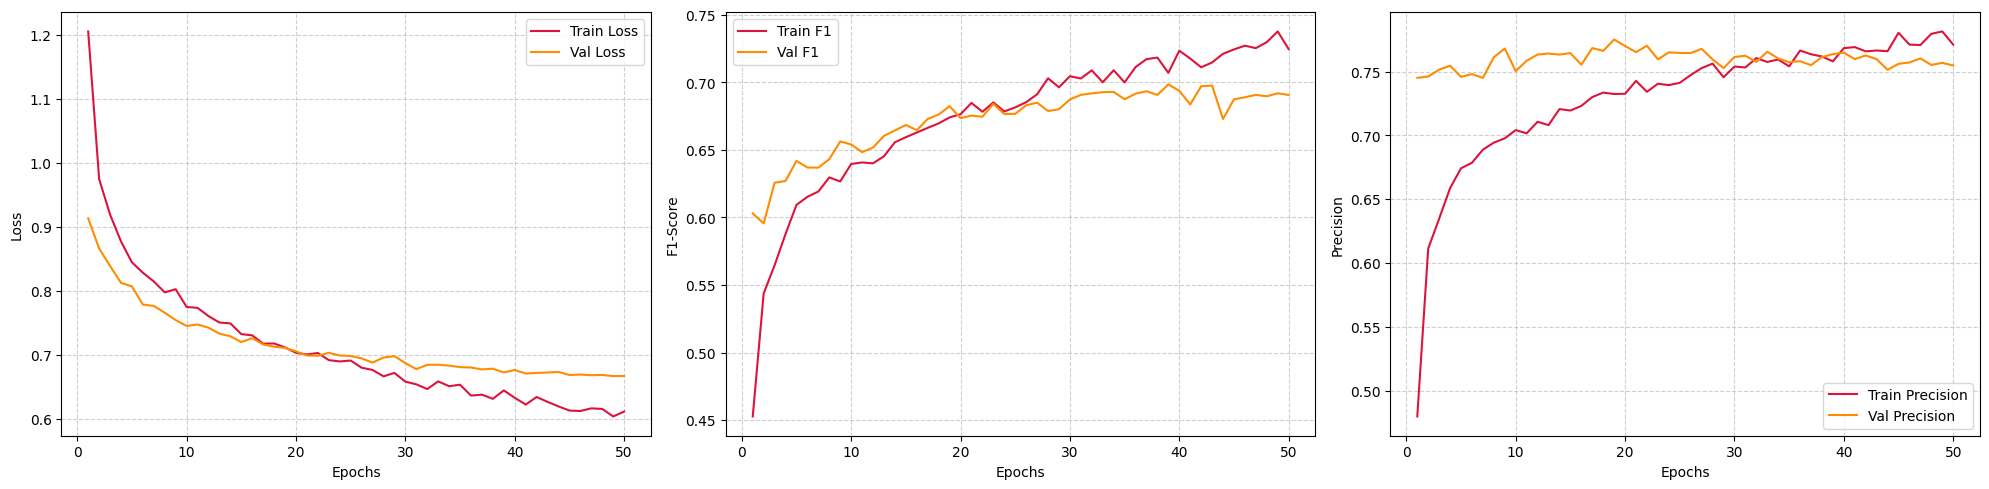

done


In [18]:
# ==========================================================
# PLOT LEARNING CURVES: PHASE 1 (INITIAL, LABELED-ONLY TRAINING)
# ==========================================================
print("start")

if 'history_initial' in globals():
    epochs_range = range(1, len(history_initial.history['loss']) + 1)
    plt.figure(figsize=(20, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, history_initial.history['loss'], label='Train Loss', color='crimson')
    plt.plot(epochs_range, history_initial.history['val_loss'], label='Val Loss', color='darkorange')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, history_initial.history['f1_score'], label='Train F1', color='crimson')
    plt.plot(epochs_range, history_initial.history['val_f1_score'], label='Val F1', color='darkorange')
    plt.xlabel('Epochs'); plt.ylabel('F1-Score'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, history_initial.history['precision'], label='Train Precision', color='crimson')
    plt.plot(epochs_range, history_initial.history['val_precision'], label='Val Precision', color='darkorange')
    plt.xlabel('Epochs'); plt.ylabel('Precision'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig("ResNet50_Wavelet_SemiSupervised_Initial_Learning_Curves_v3.pdf", format='pdf', bbox_inches='tight')
    plt.show()
else:
    print("Warning: history_initial not found. Did Phase 1 execute?")

print("done")


start


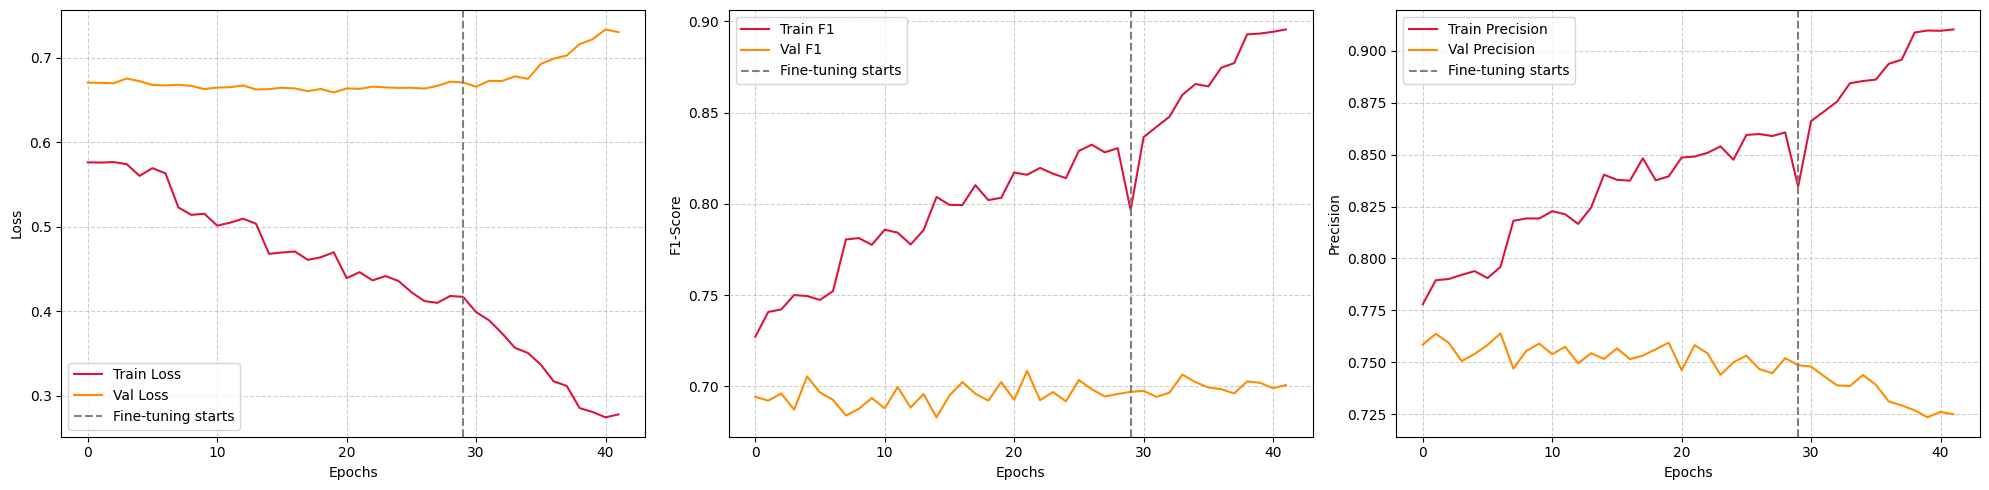

done1


In [19]:
# ==========================================================
# PLOT LEARNING CURVES: PHASE 2 (ITERATIVE SELF-TRAINING) + PHASE 3 (FINE-TUNE)
# ==========================================================
print("start")

def concat_history(h1_dict, h2_keras, key):
    return h1_dict.history[key] + h2_keras.history[key]

if 'history_final' in globals() and 'history_finetune' in globals():
    self_train_end = len(history_final.history['loss'])

    plt.figure(figsize=(20, 5))

    plt.subplot(1, 3, 1)
    plt.plot(concat_history(history_final, history_finetune, 'loss'), label='Train Loss', color='crimson')
    plt.plot(concat_history(history_final, history_finetune, 'val_loss'), label='Val Loss', color='darkorange')
    plt.axvline(self_train_end, linestyle='--', color='gray', label='Fine-tuning starts')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 3, 2)
    plt.plot(concat_history(history_final, history_finetune, 'f1_score'), label='Train F1', color='crimson')
    plt.plot(concat_history(history_final, history_finetune, 'val_f1_score'), label='Val F1', color='darkorange')
    plt.axvline(self_train_end, linestyle='--', color='gray', label='Fine-tuning starts')
    plt.xlabel('Epochs'); plt.ylabel('F1-Score'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 3, 3)
    plt.plot(concat_history(history_final, history_finetune, 'precision'), label='Train Precision', color='crimson')
    plt.plot(concat_history(history_final, history_finetune, 'val_precision'), label='Val Precision', color='darkorange')
    plt.axvline(self_train_end, linestyle='--', color='gray', label='Fine-tuning starts')
    plt.xlabel('Epochs'); plt.ylabel('Precision'); plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig("ResNet50_Wavelet_SemiSupervised_Final_Learning_Curves_v3.pdf", format='pdf', bbox_inches='tight')
    plt.show()
else:
    print("Warning: history_final / history_finetune not found.")

print("done1")


In [20]:
# ==========================================================
# FINAL EVALUATION: TRAINING, VALIDATION, AND TEST SETS  (v2)
# ==========================================================
# NEW: a separate, non-augmented generator for evaluating the training set,
# so "training metrics" reflect the real images rather than an augmented
# view of them (train_combined_generator itself still has augment=True,
# which is correct for actual training, just not for this metrics readout).
print("start")

train_eval_generator = ResNetWaveletGenerator(
    train_combined_dir, shuffle=False, labeled=True, augment=False,
    class_indices=train_labeled_generator.class_indices
)

print("\n--- Evaluating Training Dataset (labeled + pseudo-labeled, unaugmented view) ---")
train_results = model.evaluate(train_eval_generator, verbose=1)

print("\n--- Evaluating Validation Dataset ---")
val_results = model.evaluate(val_generator, verbose=1)

print("\n--- Evaluating Test Dataset (unseen) ---")
test_results = model.evaluate(test_generator, verbose=1)

train_loss, train_acc, train_f1, train_precision, train_recall = train_results
val_loss, val_acc, val_f1, val_precision, val_recall = val_results
test_loss, test_acc, test_f1, test_precision, test_recall = test_results

for name, (loss, acc, f1, prec, rec) in [
    ("TRAINING", (train_loss, train_acc, train_f1, train_precision, train_recall)),
    ("VALIDATION", (val_loss, val_acc, val_f1, val_precision, val_recall)),
    ("TESTING (UNSEEN DATA)", (test_loss, test_acc, test_f1, test_precision, test_recall)),
]:
    print("\n" + "=" * 40)
    print(f"{name} METRICS")
    print("=" * 40)
    print(f"Loss      : {loss:.4f}")
    print(f"Accuracy  : {acc*100:.2f}%")
    print(f"F1-Score  : {f1*100:.2f}%")
    print(f"Precision : {prec*100:.2f}%")
    print(f"Recall    : {rec*100:.2f}%")

print("done1")


start

--- Evaluating Training Dataset (labeled + pseudo-labeled, unaugmented view) ---
250/250 [==============================] - 102s 404ms/step - loss: 0.2849 - accuracy: 0.9039 - f1_score: 0.8499 - precision: 0.8739 - recall: 0.8157

--- Evaluating Validation Dataset ---
93/93 [==============================] - 39s 417ms/step - loss: 0.6779 - accuracy: 0.7052 - f1_score: 0.7064 - precision: 0.7386 - recall: 0.6546

--- Evaluating Test Dataset (unseen) ---
92/92 [==============================] - 43s 465ms/step - loss: 0.6844 - accuracy: 0.7017 - f1_score: 0.6995 - precision: 0.7398 - recall: 0.6510

TRAINING METRICS
Loss      : 0.2849
Accuracy  : 90.39%
F1-Score  : 84.99%
Precision : 87.39%
Recall    : 81.57%

VALIDATION METRICS
Loss      : 0.6779
Accuracy  : 70.52%
F1-Score  : 70.64%
Precision : 73.86%
Recall    : 65.46%

TESTING (UNSEEN DATA) METRICS
Loss      : 0.6844
Accuracy  : 70.17%
F1-Score  : 69.95%
Precision : 73.98%
Recall    : 65.10%
done1


In [21]:
# ==========================================================
# INFERENCE & CLASSIFICATION REPORT (Test Set)
# ==========================================================
print("start")

predictions_test = model.predict(test_generator, verbose=1)
predicted_classes_test = np.argmax(predictions_test, axis=1)
true_classes_test = test_generator.labels

print("\nClassification Report:")
print(classification_report(true_classes_test, predicted_classes_test, target_names=class_names))

print("done1")


start
92/92 [==============================] - 36s 383ms/step

Classification Report:
              precision    recall  f1-score   support

      Benign       0.58      0.56      0.57       888
   Malignant       0.72      0.75      0.74      1266
      Normal       0.81      0.78      0.79       789

    accuracy                           0.70      2943
   macro avg       0.70      0.70      0.70      2943
weighted avg       0.70      0.70      0.70      2943

done1


start


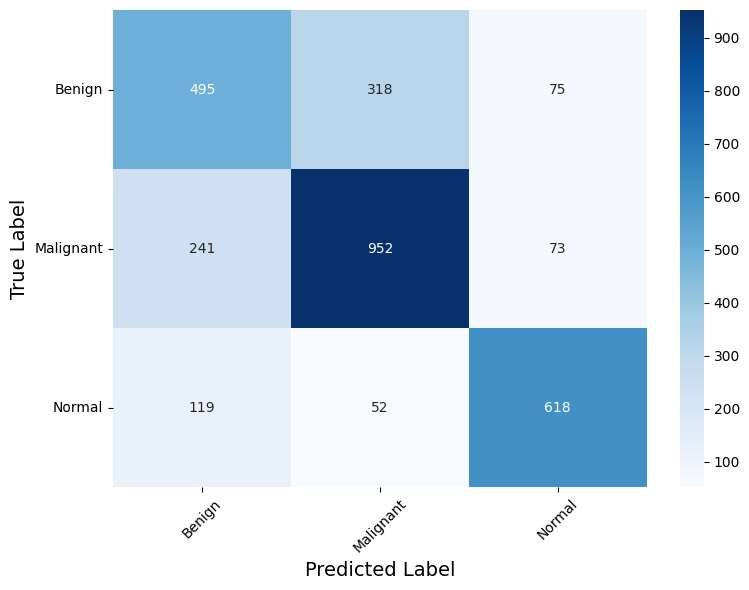

done1


In [22]:
# ==========================================================
# CONFUSION MATRIX PLOT (Test Set)
# ==========================================================
print("start")

cm = confusion_matrix(true_classes_test, predicted_classes_test)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("ResNet50_Wavelet_SemiSupervised_confusion_matrix_test_v3.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("done1")


## Notes & tunable hyperparameters (v3)

- **`AUGMENT_TRAIN`** -- currently flip-only, on purpose (see intro note on the mixed-in balancing
  copies). If train/val gap is still large after this run, resist the urge to add rotation/zoom back
  in wholesale -- it will double-augment the ~10% of images that are already synthetic balancing
  copies. Safer next steps if flip alone isn't enough: mild additive Gaussian noise (not resampling-
  based, so it doesn't compound), or fixing the upstream pipeline to tag augmented files so this
  generator can skip them specifically.
- **`DROPOUT_RATE` / `L2_REG`** -- if v2 now *underfits* (train and val F1 both mediocre and close
  together), ease these back down slightly before touching architecture.
- **`FINETUNE_UNFREEZE_LAST_N` (15)** -- if val F1 still plateaus far below train F1 during Phase 3,
  drop this further (e.g. 5-10) or skip backbone fine-tuning entirely and only fine-tune the fusion
  head.
- **`PER_CLASS_THRESHOLD` / `MAX_ACCEPT_PER_CLASS_PER_ITER` (NEW in v3)** -- these replace the old
  single global `CONFIDENCE_THRESHOLD`. Keep watching `iteration_class_counts` (printed at the end
  of Phase 2): if Normal is still dominating despite the higher 0.93 bar and the 200 cap, lower the
  cap further (e.g. 100) or raise its threshold again (e.g. 0.96). If Malignant is still barely
  represented even at 0.85, that may mean the model genuinely struggles to be confident on Malignant
  rather than being under-thresholded -- in that case, more pseudo-labels won't help; the fix is
  elsewhere (see the note on skipping self-training / class weighting below).
- **`CLASS_WEIGHT_MODE`** was left off in v1/v2 out of respect for the earlier decision to remove the
  Malignant-boost weighting. Given v2's evidence that self-training was independently re-skewing the
  dataset toward Normal, it may now be worth revisiting -- setting `CLASS_WEIGHT_MODE = 'balanced'`
  for Phase 3 (fine-tuning only) would compute weights from the actual post-self-training class
  distribution, directly counteracting whatever skew the capped/thresholded loop still lets through.
- **`SELFTRAIN_EARLYSTOP_PATIENCE` (3)** -- raise if iterations are stopping before they've had a
  chance to actually fit the newly added pseudo-labeled data; lower if individual iterations are
  still overfitting to the current combined set.

- Wavelet settings (`WAVELET_NAME`, `WAVELET_LEVEL`) unchanged from v1.
- All checkpoints now save with a `_v2` suffix so they never overwrite your v1 `.h5` files -- you
  can compare both side by side.
